In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from networks.pose_cnn import PoseCNN  # 导入PoseCNN模型

/root/miniconda3/envs/lite-mono/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 设置随机种子确保结果可重复
torch.manual_seed(42)
np.random.seed(42)

# 设置计算设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 配置参数
batch_size = 4
height = 192
width = 640
num_input_frames = 2  # 输入帧数（例如相邻帧）

# 创建模拟输入数据 - 两帧连接的图像
input_tensor = torch.rand(batch_size, 3 * num_input_frames, height, width).to(device)
print(f"模型输入维度: {input_tensor.shape}")

# 创建PoseCNN模型 (pose_set)
pose_set = PoseCNN(num_input_frames=num_input_frames).to(device)

# 打印模型结构
print(f"\nPoseCNN模型结构:")
print(pose_set)

# 执行前向传播 - PoseCNN
print("\n执行PoseCNN前向传播...")
with torch.no_grad():
    axisangle, translation = pose_set(input_tensor)

# 打印PoseCNN输出维度和值
print("\nPoseCNN输出维度:")
print(f"旋转轴角向量: {axisangle.shape}")
print(f"平移向量: {translation.shape}")

print("\nPoseCNN输出样本值:")
print(f"旋转轴角向量:")
print(axisangle.cpu().numpy())
print(f"平移向量:")
print(translation.cpu().numpy())

print("\n完整模型测试完成！")

使用设备: cuda
模型输入维度: torch.Size([4, 6, 192, 640])

PoseCNN模型结构:
PoseCNN(
  (pose_conv): Conv2d(256, 6, kernel_size=(1, 1), stride=(1, 1))
  (relu): ReLU(inplace=True)
  (net): ModuleList(
    (0): Conv2d(6, 16, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5-6): 2 x Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  )
)

执行PoseCNN前向传播...

PoseCNN输出维度:
旋转轴角向量: torch.Size([4, 1, 1, 3])
平移向量: torch.Size([4, 1, 1, 3])

PoseCNN输出样本值:
旋转轴角向量:
[[[[-8.3303254e-05 -3.5237084e-04  8.2920938e-05]]]


 [[[-8.2426632e-05 -3.5290240e-04  8.3868334e-05]]]


 [[[-8.2184364e-05 -3.5279899e-04  8.3566454e-05]]]


 [[[-8.2781167e-05 -3.5314649e-04  8.3802282e-05]]]]
平移向量:
[[[[1.14

In [4]:
# 加载pose.pth权重（包含整个PoseCNN模型）
pose_path = "../autodl-tmp/KITTI_192x640_models/pose.pth"

print(f"\n正在加载pose.pth权重: {pose_path}")

try:
    # 加载权重
    state_dict = torch.load(pose_path, map_location=device)
    print(f"成功加载权重文件，包含 {len(state_dict)} 个参数")
    
    # 打印权重参数名称
    print("\n权重参数名称:")
    for key in state_dict.keys():
        print(f"  {key}: {state_dict[key].shape}")
    
    # 尝试加载权重到模型
    missing_keys, unexpected_keys = pose_set.load_state_dict(state_dict, strict=False)
    
    print(f"\n加载结果:")
    print(f"缺失的键: {missing_keys}")
    print(f"多余的键: {unexpected_keys}")
    
    if not missing_keys and not unexpected_keys:
        print("✅ pose.pth包含完整的PoseCNN模型权重")
    elif missing_keys:
        print("❌ pose.pth缺少部分权重参数")
    elif unexpected_keys:
        print("⚠️ pose.pth包含多余的权重参数")
        
except Exception as e:
    print(f"❌ 加载权重失败: {e}")

# 设置为评估模式
pose_set.eval()

# 测试加载权重后的模型
print("\n测试加载权重后的模型...")
with torch.no_grad():
    axisangle_loaded, translation_loaded = pose_set(input_tensor)

print("加载权重后的输出:")
print(f"旋转轴角向量: {axisangle_loaded.shape}")
print(f"平移向量: {translation_loaded.shape}")
print(f"旋转轴角样本值: {axisangle_loaded.cpu().numpy()}")
print(f"平移样本值: {translation_loaded.cpu().numpy()}")

print("\n权重加载测试完成！")


正在加载pose.pth权重: ../autodl-tmp/KITTI_192x640_models/pose.pth
成功加载权重文件，包含 16 个参数

权重参数名称:
  pose_conv.weight: torch.Size([6, 256, 1, 1])
  pose_conv.bias: torch.Size([6])
  net.0.weight: torch.Size([16, 6, 7, 7])
  net.0.bias: torch.Size([16])
  net.1.weight: torch.Size([32, 16, 5, 5])
  net.1.bias: torch.Size([32])
  net.2.weight: torch.Size([64, 32, 3, 3])
  net.2.bias: torch.Size([64])
  net.3.weight: torch.Size([128, 64, 3, 3])
  net.3.bias: torch.Size([128])
  net.4.weight: torch.Size([256, 128, 3, 3])
  net.4.bias: torch.Size([256])
  net.5.weight: torch.Size([256, 256, 3, 3])
  net.5.bias: torch.Size([256])
  net.6.weight: torch.Size([256, 256, 3, 3])
  net.6.bias: torch.Size([256])

加载结果:
缺失的键: []
多余的键: []
✅ pose.pth包含完整的PoseCNN模型权重

测试加载权重后的模型...
加载权重后的输出:
旋转轴角向量: torch.Size([4, 1, 1, 3])
平移向量: torch.Size([4, 1, 1, 3])
旋转轴角样本值: [[[[-0.00086131  0.00329085 -0.00125853]]]


 [[[-0.0010218  -0.00842716 -0.00157605]]]


 [[[-0.00053436 -0.00329411 -0.00139919]]]


 [[[-0.00050191  

In [17]:
# 修改后的代码
import torch
import cv2
import numpy as np
from PIL import Image
import torchvision.transforms as transforms

# 设置变换操作
transform = transforms.Compose([
    transforms.Resize((192, 640)),  # 调整为模型所需尺寸
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 读取两帧图像
frame1_path = "../autodl-tmp/data/kitti_c/gaussian_noise/2/kitti_data/2011_09_26/2011_09_26_drive_0002_sync/image_02/data/0000000006.png"
frame2_path = "../autodl-tmp/data/kitti_c/gaussian_noise/2/kitti_data/2011_09_26/2011_09_26_drive_0002_sync/image_02/data/0000000009.png"

frame1 = Image.open(frame1_path).convert('RGB')
frame2 = Image.open(frame2_path).convert('RGB')

# 预处理图像
frame1_tensor = transform(frame1).unsqueeze(0).to(device)
frame2_tensor = transform(frame2).unsqueeze(0).to(device)

# 将两帧图像连接起来作为输入
input_tensor = torch.cat([frame1_tensor, frame2_tensor], dim=1)
    
# PoseCNN前向传播
with torch.no_grad():
    poses = pose_set(input_tensor)
        
# 首先检查输出的形状
print("Rotation tensor shape:", poses[0].shape)
print("Translation tensor shape:", poses[1].shape)

# 根据实际形状提取参数
# 假设输出形状是 [batch, num_poses, 3] 或类似
rotation = poses[0].cpu().numpy()  # 获取所有旋转参数
translation = poses[1].cpu().numpy()  # 获取所有平移参数

# 提取两帧之间的位姿
# 这里假设第一个输出是第一帧的位姿，第二个输出是第二帧的位姿
# 实际情况可能需要根据模型输出调整
if len(rotation) >= 2 and len(translation) >= 2:
    rotation1 = rotation[0]
    translation1 = translation[0]
    rotation2 = rotation[1]
    translation2 = translation[1]
else:
    # 如果模型只输出一个位姿，可能是相对位姿
    rotation1 = np.zeros(3)  # 假设第一帧是原点
    translation1 = np.zeros(3)
    rotation2 = rotation[0]
    translation2 = translation[0]

print("第一帧旋转参数:", rotation1)
print("第一帧平移参数:", translation1)
print("第二帧旋转参数:", rotation2)
print("第二帧平移参数:", translation2)

# 计算相对变换
def axis_angle_to_rotation_matrix(axis_angle):
    """将轴角表示转换为旋转矩阵"""
    angle = np.linalg.norm(axis_angle)
    if angle < 1e-6:
        return np.eye(3)  # 如果角度接近零，返回单位矩阵
    axis = axis_angle / angle
    # 使用Rodrigues公式
    return cv2.Rodrigues(axis_angle)[0]

# 计算旋转矩阵
R1 = axis_angle_to_rotation_matrix(rotation1)
R2 = axis_angle_to_rotation_matrix(rotation2)

# 计算相对旋转 R_1to2 = R2 * R1^T
R_1to2 = R2 @ R1.T

# 计算相对平移 t_1to2 = t2 - R_1to2 * t1
t_1to2 = translation2 - R_1to2 @ translation1

# 将相对旋转转回轴角表示
r_1to2 = cv2.Rodrigues(R_1to2)[0].flatten()

print("\n第一帧到第二帧的相对旋转:", r_1to2)
print("第一帧到第二帧的相对平移:", t_1to2)

Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1, 1, 1, 3])
第一帧旋转参数: [0. 0. 0.]
第一帧平移参数: [0. 0. 0.]
第二帧旋转参数: [[[-0.00188058  0.00233441 -0.00115673]]]
第二帧平移参数: [[[-0.00038258  0.001186   -0.11343609]]]

第一帧到第二帧的相对旋转: [-0.00188058  0.00233441 -0.00115673]
第一帧到第二帧的相对平移: [[[-0.00038258  0.001186   -0.11343609]]]


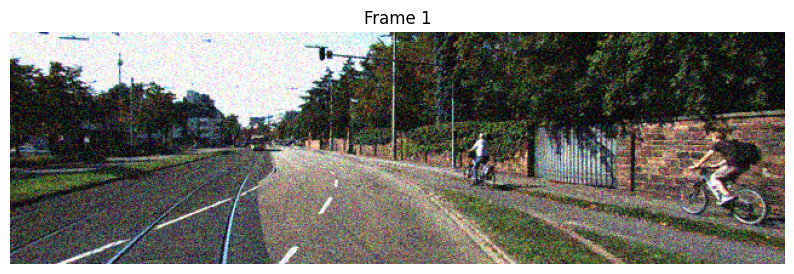


使用pose_set模型的测试完成！


In [18]:
# 显示图像（和原脚本一样）
def tensor_to_image(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """
    将归一化的图像张量转换为可显示的图像
    """
    # 确保张量在CPU上
    tensor = tensor.cpu().clone()
    
    # 如果是批次，只取第一个图像
    if tensor.dim() == 4:
        tensor = tensor[0]
    
    # 反归一化
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    
    # 将张量转换为numpy数组并调整通道顺序
    image = tensor.numpy()
    image = np.transpose(image, (1, 2, 0))
    
    # 确保值在[0, 1]范围内
    image = np.clip(image, 0, 1)
    
    return image

# 显示图像
img = tensor_to_image(frame1_tensor)
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.title('Frame 1')
plt.show()

print("\n使用pose_set模型的测试完成！")

In [19]:
import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# 数据集类，用于加载连续图像
class ImageSequenceDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        # 按照数字顺序排列文件名
        self.image_paths = sorted(glob.glob(os.path.join(folder_path, '*.png')))
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths) - 1  # 减1是因为我们需要相邻的两帧
    
    def __getitem__(self, idx):
        # 获取当前帧和下一帧
        current_img_path = self.image_paths[idx]
        next_img_path = self.image_paths[idx + 1]
        
        current_image = Image.open(current_img_path).convert('RGB')
        next_image = Image.open(next_img_path).convert('RGB')
        
        if self.transform:
            current_image = self.transform(current_image)
            next_image = self.transform(next_image)
            
        return current_image, next_image, current_img_path, next_img_path

def analyze_motion_constraints(rotations, translations):
    """分析运动约束模式"""
    # 转换为numpy数组
    rot_array = np.array(rotations)
    trans_array = np.array(translations)
    
    # 使用PCA分析旋转和平移
    pca_rot = PCA(n_components=3)
    pca_trans = PCA(n_components=3)
    
    pca_rot.fit(rot_array)
    pca_trans.fit(trans_array)
    
    # 获取主轴和方差比例
    rot_axes = pca_rot.components_
    rot_variance = pca_rot.explained_variance_ratio_
    trans_axes = pca_trans.components_
    trans_variance = pca_trans.explained_variance_ratio_
    
    # 计算平均旋转和平移
    mean_rot = np.mean(rot_array, axis=0)
    mean_trans = np.mean(trans_array, axis=0)
    
    # 计算旋转和平移的幅度
    rot_magnitudes = np.linalg.norm(rot_array, axis=1)
    trans_magnitudes = np.linalg.norm(trans_array, axis=1)
    
    # 计算连续帧之间的平移距离
    frame_distances = trans_magnitudes
    
    # 分析结果
    results = {
        'rot_axes': rot_axes,
        'rot_variance': rot_variance,
        'trans_axes': trans_axes,
        'trans_variance': trans_variance,
        'mean_rot': mean_rot,
        'mean_trans': mean_trans,
        'rot_magnitudes': rot_magnitudes,
        'trans_magnitudes': trans_magnitudes,
        'frame_distances': frame_distances
    }
    
    return results

def visualize_results(rotations, translations, results):
    """可视化分析结果"""
    rot_array = np.array(rotations)
    trans_array = np.array(translations)
    
    # 创建图表
    fig = plt.figure(figsize=(18, 12))
    
    # 1. 平移轨迹
    ax1 = fig.add_subplot(231, projection='3d')
    ax1.scatter(trans_array[:, 0], trans_array[:, 1], trans_array[:, 2], c='b', marker='o')
    ax1.set_title('Camera Translation Trajectory')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    
    # 2. 旋转分布
    ax2 = fig.add_subplot(232, projection='3d')
    ax2.scatter(rot_array[:, 0], rot_array[:, 1], rot_array[:, 2], c='r', marker='^')
    ax2.set_title('Camera Rotation Distribution')
    ax2.set_xlabel('Rotation X')
    ax2.set_ylabel('Rotation Y')
    ax2.set_zlabel('Rotation Z')
    
    # 3. 平移主轴
    ax3 = fig.add_subplot(233)
    bars = ax3.bar(['X', 'Y', 'Z'], results['trans_variance'] * 100)
    ax3.set_title('Translation Principal Components (%)')
    ax3.set_ylabel('Variance Explained (%)')
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%', 
                ha='center', va='bottom')
    ax3.set_ylim(0, 105)
    
    # 4. 旋转主轴
    ax4 = fig.add_subplot(234)
    bars = ax4.bar(['X', 'Y', 'Z'], results['rot_variance'] * 100)
    ax4.set_title('Rotation Principal Components (%)')
    ax4.set_ylabel('Variance Explained (%)')
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%', 
                ha='center', va='bottom')
    ax4.set_ylim(0, 105)
    
    # 5. 平移和旋转幅度的相关性
    ax5 = fig.add_subplot(235)
    ax5.scatter(results['rot_magnitudes'], results['trans_magnitudes'])
    ax5.set_title('Rotation vs Translation Magnitude')
    ax5.set_xlabel('Rotation Magnitude')
    ax5.set_ylabel('Translation Magnitude')
    
    # 计算相关系数
    corr = np.corrcoef(results['rot_magnitudes'], results['trans_magnitudes'])[0, 1]
    ax5.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax5.transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', alpha=0.1))
    
    # 6. 连续帧之间的位移距离
    ax6 = fig.add_subplot(236)
    ax6.plot(results['frame_distances'], marker='o')
    ax6.set_title('Inter-frame Translation Distance')
    ax6.set_xlabel('Frame Pair Index')
    ax6.set_ylabel('Distance')
    
    plt.tight_layout()
    plt.savefig('motion_analysis.png', dpi=300)
    plt.show()
    
    # 打印主要发现
    print("\n=== 运动约束分析结果 ===")
    print(f"平移主轴方差占比: {results['trans_variance'] * 100}")
    print(f"旋转主轴方差占比: {results['rot_variance'] * 100}")
    
    # 判断运动类型
    if results['trans_variance'][0] > 80:
        print("相机主要沿单一轴运动")
    elif results['trans_variance'][0] + results['trans_variance'][1] > 95:
        print("相机主要在平面内运动")
    
    if results['rot_variance'][0] > 80:
        print("相机旋转主要围绕单一轴")
    
    print(f"平移-旋转相关系数: {corr:.3f}")
    if abs(corr) > 0.7:
        print("平移和旋转高度相关，可能是绕固定点旋转或沿固定曲线运动")
    
    # 计算平均帧间距离和标准差
    mean_dist = np.mean(results['frame_distances'])
    std_dist = np.std(results['frame_distances'])
    print(f"平均帧间距离: {mean_dist:.4f}")
    print(f"帧间距离标准差: {std_dist:.4f}")
    print(f"变异系数: {std_dist/mean_dist:.4f}")
    
    if std_dist/mean_dist < 0.2:
        print("相机运动速度相对均匀")
    else:
        print("相机运动速度变化较大")


In [24]:
def main():
    # 设置参数
    image_folder = '../autodl-tmp/data/kitti_c/glass_blur/2/kitti_data/2011_09_26/2011_09_26_drive_0002_sync/image_02/data'  # 替换为您的图像文件夹路径
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    
    # 图像预处理
    transform = transforms.Compose([
        transforms.Resize((192, 640)),  # 调整到您模型需要的尺寸
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                             std=[0.229, 0.224, 0.225])
    ])
    
    # 创建数据集和数据加载器
    dataset = ImageSequenceDataset(image_folder, transform=transform)
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
    
    # 确保模型在评估模式
    pose_set.eval()
    
    # 存储所有位姿
    all_rotations = []
    all_translations = []
    
    # 处理每个图像对
    for frame1, frame2, frame1_path, frame2_path in dataloader:
        # 将图像移动到设备
        frame1 = frame1.to(device)
        frame2 = frame2.to(device)
        
        # 堆叠两帧作为输入
        input_tensor = torch.cat([frame1, frame2], dim=1)
        
        # 使用完整模型提取位姿
        with torch.no_grad():
            poses = pose_set(input_tensor)
            
        # 检查模型输出形状
        print("Rotation tensor shape:", poses[0].shape)
        print("Translation tensor shape:", poses[1].shape)
        
        # 根据实际输出形状提取参数
        # 假设输出形状是 [batch, num_poses, 3] 或类似
        rotation = poses[0][0, 0].cpu().numpy()  # 根据实际形状调整索引
        translation = poses[1][0, 0].cpu().numpy()
        
        all_rotations.append(rotation)
        all_translations.append(translation)
        
        print(f"处理: {os.path.basename(frame1_path[0])} -> {os.path.basename(frame2_path[0])}")
        print(f"  旋转: {rotation}")
        print(f"  平移: {translation}")
    
    # 分析运动约束
    results = analyze_motion_constraints(all_rotations, all_translations)
    
    # 可视化结果
    visualize_results(all_rotations, all_translations, results)

In [25]:
if __name__ == "__main__":
    main()

Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1, 1, 1, 3])
处理: 0000000000.png -> 0000000003.png
  旋转: [[ 0.00012583 -0.00020185  0.00011726]]
  平移: [[ 0.00076777  0.00211338 -0.13676138]]
Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1, 1, 1, 3])
处理: 0000000003.png -> 0000000006.png
  旋转: [[-0.00273264 -0.00062743 -0.00067256]]
  平移: [[-0.00112846  0.00109223 -0.12090939]]
Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1, 1, 1, 3])
处理: 0000000006.png -> 0000000009.png
  旋转: [[-0.0017717   0.00050146 -0.00174881]]
  平移: [[-0.00110607  0.00133308 -0.10184214]]
Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1, 1, 1, 3])
处理: 0000000009.png -> 0000000012.png
  旋转: [[-0.00025701  0.00793399 -0.00248195]]
  平移: [[-0.00095384  0.00142441 -0.13585891]]
Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1,

ValueError: Found array with dim 3. PCA expected <= 2.

In [26]:
if __name__ == "__main__":
    main()

Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1, 1, 1, 3])
处理: 0000000000.png -> 0000000003.png
  旋转: [[ 0.00012583 -0.00020185  0.00011726]]
  平移: [[ 0.00076777  0.00211338 -0.13676138]]
Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1, 1, 1, 3])
处理: 0000000003.png -> 0000000006.png
  旋转: [[-0.00273264 -0.00062743 -0.00067256]]
  平移: [[-0.00112846  0.00109223 -0.12090939]]
Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1, 1, 1, 3])
处理: 0000000006.png -> 0000000009.png
  旋转: [[-0.0017717   0.00050146 -0.00174881]]
  平移: [[-0.00110607  0.00133308 -0.10184214]]
Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1, 1, 1, 3])
处理: 0000000009.png -> 0000000012.png
  旋转: [[-0.00025701  0.00793399 -0.00248195]]
  平移: [[-0.00095384  0.00142441 -0.13585891]]
Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1,

ValueError: Found array with dim 3. PCA expected <= 2.

In [27]:
if __name__ == "__main__":
    main()

Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1, 1, 1, 3])
处理: 0000000000.png -> 0000000003.png
  旋转: [[ 0.00012583 -0.00020185  0.00011726]]
  平移: [[ 0.00076777  0.00211338 -0.13676138]]
Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1, 1, 1, 3])
处理: 0000000003.png -> 0000000006.png
  旋转: [[-0.00273264 -0.00062743 -0.00067256]]
  平移: [[-0.00112846  0.00109223 -0.12090939]]
Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1, 1, 1, 3])
处理: 0000000006.png -> 0000000009.png
  旋转: [[-0.0017717   0.00050146 -0.00174881]]
  平移: [[-0.00110607  0.00133308 -0.10184214]]
Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1, 1, 1, 3])
处理: 0000000009.png -> 0000000012.png
  旋转: [[-0.00025701  0.00793399 -0.00248195]]
  平移: [[-0.00095384  0.00142441 -0.13585891]]
Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1,

ValueError: Found array with dim 3. PCA expected <= 2.

In [28]:
if __name__ == "__main__":
    main()

Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1, 1, 1, 3])
处理: 0000000000.png -> 0000000003.png
  旋转: [[ 0.00012583 -0.00020185  0.00011726]]
  平移: [[ 0.00076777  0.00211338 -0.13676138]]
Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1, 1, 1, 3])
处理: 0000000003.png -> 0000000006.png
  旋转: [[-0.00273264 -0.00062743 -0.00067256]]
  平移: [[-0.00112846  0.00109223 -0.12090939]]
Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1, 1, 1, 3])
处理: 0000000006.png -> 0000000009.png
  旋转: [[-0.0017717   0.00050146 -0.00174881]]
  平移: [[-0.00110607  0.00133308 -0.10184214]]
Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1, 1, 1, 3])
处理: 0000000009.png -> 0000000012.png
  旋转: [[-0.00025701  0.00793399 -0.00248195]]
  平移: [[-0.00095384  0.00142441 -0.13585891]]
Rotation tensor shape: torch.Size([1, 1, 1, 3])
Translation tensor shape: torch.Size([1,

ValueError: Found array with dim 3. PCA expected <= 2.